### Adding missing data to Pend Oreille

The goal is to find out why there is a gap between the Pend Oreille River and the Lake on our plots, and then possibly fix it.

TL;DR

This is a working example of how to add to a GeoDataFrame.  It also shows how to find nearest points and compute lengths.

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

dbpath = '/Users/telliott/data/'
fn = 'North_America_Lakes_and_Rivers.zip'
na_rivers = gpd.read_file(dbpath + fn)
sel = na_rivers['NameEn'].str.contains("Pend Oreille")
po_river = na_rivers[sel]

In [3]:
fn = 'North_America_Lakes.zip'
na_lakes = gpd.read_file(dbpath+fn)
sel = na_lakes['NameEn'].str.contains('Pend Oreille')
po_lake = na_lakes[sel]

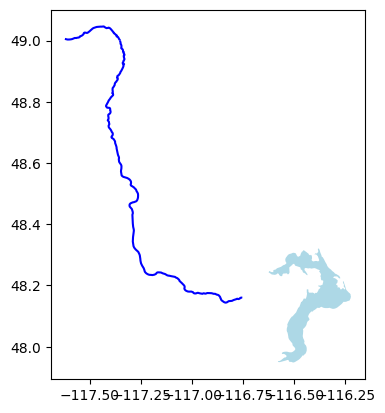

In [4]:
ax = po_river.plot(color='b')
po_lake.plot(ax=ax,color='lightblue')
plt.show()

`po_river` has two rows, one for the part in Canada and the second for the part in the USA.  `po_lake` has only a single row, a `LINESTRING` object.

In [5]:
river_geom = po_river.iloc[1].geometry
lake_geom = po_lake.geometry
L = list(river_geom.coords)
len(L)
print(L[0],L[-1])

(-116.754568877487, 48.1599716677888) (-117.353364035974, 49.0003164329327)


The river data appears to run generally east to west.  However, we should not assume that there aren't some other points in `L` that are closer.  One idea is to look at the `bounds`.

In [6]:
river_geom.bounds

(-117.421307883071, 48.1439997098789, -116.754568877487, 49.0003164329327)

### nearest_points

In [7]:
from shapely.ops import nearest_points
points = nearest_points(river_geom,lake_geom)
print(points)

(6229    POINT (-116.75457 48.15997)
Name: geometry, dtype: geometry, 6229    POINT (-116.62599 48.24265)
Name: geometry, dtype: geometry)


I'm struggling to find the right way to get these plotted.  This doesn't work

In [8]:
def display(gdf):
    ax = po_river.plot(color='b')
    po_lake.plot(ax=ax,color='lightblue')
    gdf.plot(ax=ax)
    plt.show()

# display(points)

In [9]:
print(type(points))

<class 'tuple'>


In [10]:
points[0]

6229    POINT (-116.75457 48.15997)
Name: geometry, dtype: geometry

In [11]:
points[1]

6229    POINT (-116.62599 48.24265)
Name: geometry, dtype: geometry

For the moment, do it by hand.

In [12]:
D = { 'name':['river','lake'],
      'LON':[-116.75457,-116.62286],
      'LAT':[48.15997,48.24656] }
df = pd.DataFrame(D)
df

,name,LON,LAT
0,river,-116.75457,48.15997
1,lake,-116.62286,48.24656


In [13]:
from shapely import Point
geometry = [Point(xy) for xy in zip(df.LON, df.LAT)]
gdf = gpd.GeoDataFrame(df,geometry=geometry,crs=po_river.crs)
print(gdf)

    name        LON       LAT                     geometry
0  river -116.75457  48.15997  POINT (-116.75457 48.15997)
1   lake -116.62286  48.24656  POINT (-116.62286 48.24656)


In [14]:
print(gdf.columns)

Index(['name', 'LON', 'LAT', 'geometry'], dtype='object')


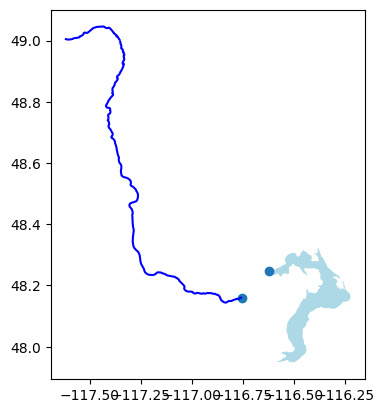

In [15]:
# from above
display(gdf)

### Size of the gap

We're missing 0.129 degrees of longitude and 0.08659 of latitude.

In [16]:
# fundamental, approximate approach
from math import cos, radians

C = 40000 # km
dx = C/360 * 0.129 * cos(radians(48))
dy = C/360 * 0.08659
length = (dx**2 + dy**2)**0.5
round(length,2)

13.58

Here's a better way:

In [17]:
import utm
from pyproj import CRS

dbpath = '/Users/telliott/data/'
po_addns = gpd.read_file(
    dbpath + 'po_addns.shp.zip')

# to get length properly we must project to correct CRS

def utm_crs_from_latlon(lat, lon):
    crs_params = dict(
        proj = 'utm',
        zone = utm.latlon_to_zone_number(lat, lon),
        south = lat < 0
        )
    return CRS.from_dict(crs_params)

utm_crs = utm_crs_from_latlon(48.2,-116.6)
print(utm_crs) 

sub = po_addns.to_crs(utm_crs)
print(sub.geometry[0])
print(sub.length)

+proj=utm +zone=11 +type=crs
LINESTRING (526404.0644849889 5343991.683102484, 524411.129314948 5344830.198400886, 523166.4076062218 5344103.82374203, 522793.4136110913 5342407.1919679, 522490.65436216904 5341197.455119945, 521066.9337879284 5339658.441673474, 521182.88584540464 5337673.630000758, 521185.69705673005 5336915.458459129, 520175.2114436488 5335918.793824149, 519526.6389227794 5334923.363112617, 519075.55416763667 5334398.095703166, 518219.3099086929 5334112.829505766)
0    15632.707337
dtype: float64


That's 15632.707337 meters.  Considering the curve, that seems pretty reasonable.

In [18]:
### Adding the points

I just take points from Google Maps.  Notice that these are in `(y,x)` order, because that's how they roll.

In [19]:
raw_points = [
[48.248589733216136, -116.64432444663814],
[48.256213458503204, -116.67112139993714],
[48.24972525370046, -116.68793039791562],
[48.23447473170333, -116.69304617990908],
[48.22360190290814, -116.69718752629615],
[48.209804691843075, -116.71643261093814],
[48.19194395801155, -116.71497095894],
[48.185122762281175, -116.71497095894],
[48.17618887113204, -116.7286130442559],
[48.167253423001256, -116.73738295624466],
[48.162541377351445, -116.74347317265425],
[48.159235, -116.749974]]
len(raw_points)

12

I am sure there is a better way to do this part.  I just copy from the original.

In [20]:
points = [(b,a) for a,b in raw_points]

In [21]:
D = {'FID':['4995'],
'Country':['USA'],
'NameEn':['Pend Oreille River'],
'NameEs':['Río Pend Oreille'],
'NameFr':['Pend Oreille River'],
'LengthKm':['15.632707'] }

df = pd.DataFrame(D)

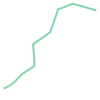

In [22]:
from shapely import LineString
# the geometry part
LS = LineString(points)
LS

In [23]:
new_pts = gpd.GeoDataFrame(
    # notice [LS]
    df,geometry=[LS],crs="EPSG:4326")
    
new_pts.to_file('po_addns.shp.zip', 
    driver='ESRI Shapefile')

In [24]:
new_pts.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

The script to write and plot the new GeoDataFrame is [here](Pend_Oreille/mk_gdf.py).

And here is the plot:

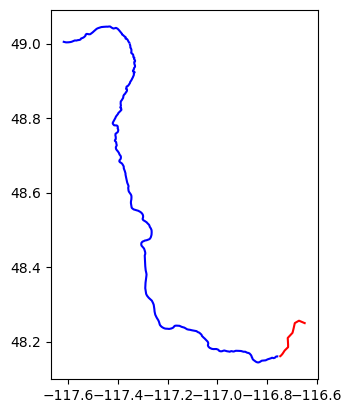

In [25]:
ax = po_river.plot(color='b')
new_pts.plot(ax=ax,color='r')
plt.show()